# Deep Learning: A Comprehensive Guide

## Chapter 7 — Sequence Models

### Hands-On Exploration: Watching Memory Decay

### `hands_on_ch7.ipynb`

This exploration builds intuition for how information fades in recurrent models as sequences grow longer. You will train a simple RNN and an LSTM of equivalent size on a sentence-completion-style task, then probe how well each preserves information about early inputs as sequence length increases.

## Learning Objectives

By the end of this notebook, you should be able to:

- Extract and visualize a recurrent model's hidden state at different sequence lengths
- Train and interpret a probing classifier that tests what information survives in a hidden state
- Compare how RNNs and LSTMs degrade differently as sequence length increases

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `tensorflow`
- No GPU required

## About the Task in This Notebook

The chapter's activity uses pre-trained RNN and LSTM models on a sentence completion task. To keep this notebook fully self-contained, we generate a small **synthetic subject-recall task** directly in the notebook: sentences of controlled length where a "subject" token appears at the very start, and the model's job is to recall it from the final hidden state — a clean, controllable version of exactly the phenomenon the chapter describes. We then train a small RNN and a small LSTM of equivalent size on this task ourselves (training takes well under a minute on CPU), so "pre-trained" in this notebook means "trained once, in the first few cells below," rather than requiring a separately-hosted checkpoint.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")


I0000 00:00:1788478087.062505    1916 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788478087.106880    1916 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788478088.678505    1916 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Generate the Subject-Recall Task

Each "sentence" is a sequence of random tokens (integers standing in for words). The very first token is the "subject." The task: given the full sequence, predict the subject from the final hidden state alone. This is exactly the kind of long-range dependency that recurrent models struggle to preserve as sequences grow longer.

In [2]:
VOCAB_SIZE = 20  # 20 possible "words," including subjects
N_SUBJECTS = 6    # first N_SUBJECTS tokens (0-5) can serve as subjects
MAX_LEN = 30


def generate_sentence(length, seed):
    rng = np.random.RandomState(seed)
    subject = rng.randint(0, N_SUBJECTS)
    filler = rng.randint(N_SUBJECTS, VOCAB_SIZE, size=length - 1)
    return np.concatenate([[subject], filler]), subject


def make_dataset(n_examples, length, seed):
    X, y = [], []
    for i in range(n_examples):
        seq, subject = generate_sentence(length, seed=seed * 100000 + i)
        X.append(seq)
        y.append(subject)
    X = np.array(X)
    X_padded = np.zeros((n_examples, MAX_LEN), dtype=np.int32)
    X_padded[:, :length] = X
    return X_padded, np.array(y), length


# Training data: a mix of sequence lengths so the model learns to handle variable length
X_train_list, y_train_list = [], []
for length in [5, 8, 12, 16, 20, 25, 30]:
    Xp, y, _ = make_dataset(150, length, seed=length)
    X_train_list.append(Xp)
    y_train_list.append(y)
X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

print(f"Training set: {X_train.shape[0]} sequences, padded to length {MAX_LEN}")


Training set: 1050 sequences, padded to length 30


## Train a Small RNN and a Small LSTM of Equivalent Size

Both models share the same embedding size and hidden size, differing only in the recurrent cell type — exactly the controlled comparison the chapter calls for.

In [3]:
if TF_AVAILABLE:
    HIDDEN_SIZE = 32

    def build_model(cell_type):
        inputs = layers.Input(shape=(MAX_LEN,))
        x = layers.Embedding(VOCAB_SIZE, 16, mask_zero=True)(inputs)
        if cell_type == "rnn":
            seq_out, hidden = layers.SimpleRNN(HIDDEN_SIZE, return_state=True)(x)
        else:
            seq_out, hidden, cell_state = layers.LSTM(HIDDEN_SIZE, return_state=True)(x)
        output = layers.Dense(N_SUBJECTS, activation="softmax")(seq_out)
        train_model = models.Model(inputs, output)
        # A second model sharing the same layers/weights, exposing the hidden state directly.
        # Because it shares the same layer instances, its weights update automatically as
        # train_model is trained -- no weight-copying required.
        hidden_model = models.Model(inputs, hidden)
        train_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return train_model, hidden_model

    rnn_model, rnn_extractor = build_model("rnn")
    lstm_model, lstm_extractor = build_model("lstm")

    print("Training RNN...")
    rnn_model.fit(X_train, y_train, epochs=6, batch_size=32, verbose=0, validation_split=0.1)
    print("Training LSTM...")
    lstm_model.fit(X_train, y_train, epochs=6, batch_size=32, verbose=0, validation_split=0.1)
    print("Done. Both models trained on the same data, same epochs, same hidden size.")
    print("rnn_extractor and lstm_extractor now expose each model's final hidden state directly.")
else:
    print("TensorFlow not available -- cannot proceed.")


Training RNN...


E0000 00:00:1788478091.827800    1916 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Training LSTM...


Done. Both models trained on the same data, same epochs, same hidden size.
rnn_extractor and lstm_extractor now expose each model's final hidden state directly.


## Part 1 — Setting Up the Probe

Build a "hidden state extractor" for each model, then feed sentences of five different lengths (5, 10, 15, 20, 30 words) and extract the hidden state after the final token.

In [4]:
if TF_AVAILABLE:
    lengths_to_probe = [5, 10, 15, 20, 30]
    probe_data = {}  # length -> (X_padded, subjects)
    for length in lengths_to_probe:
        Xp, y, _ = make_dataset(60, length, seed=length + 500)
        probe_data[length] = (Xp, y)

    print("Probe sentences generated at lengths:", lengths_to_probe)


Probe sentences generated at lengths: [5, 10, 15, 20, 30]


### Visualize Hidden States as Heatmaps

For a single example sentence at each length, visualize the final hidden state as a heatmap. Don't try to interpret individual values — focus on the overall pattern.

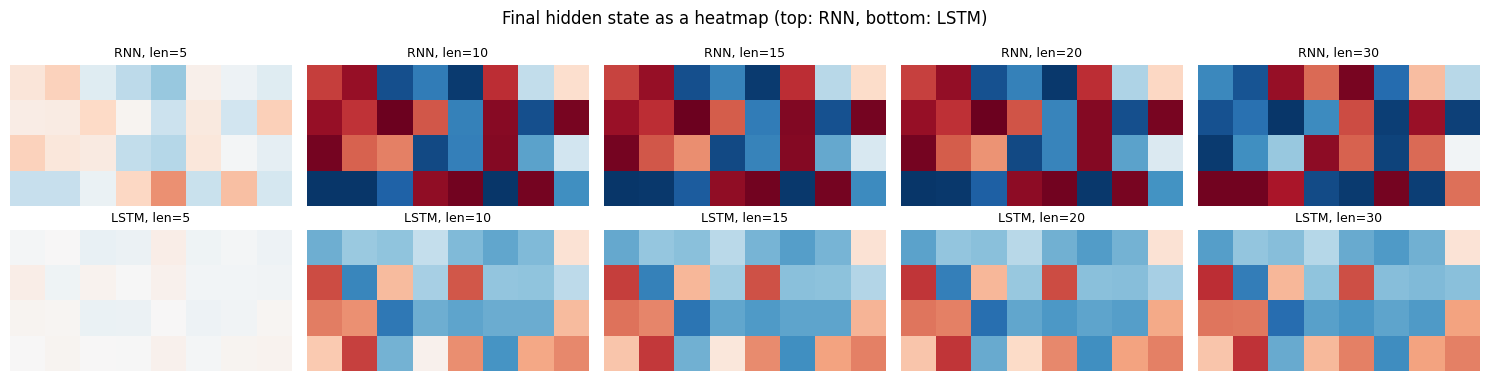

In [5]:
if TF_AVAILABLE:
    fig, axes = plt.subplots(2, len(lengths_to_probe), figsize=(15, 4))
    for col, length in enumerate(lengths_to_probe):
        Xp, y = probe_data[length]
        rnn_hidden = rnn_extractor.predict(Xp[:1], verbose=0)[0]
        lstm_hidden = lstm_extractor.predict(Xp[:1], verbose=0)[0]
        axes[0, col].imshow(rnn_hidden.reshape(4, 8), cmap="RdBu_r", vmin=-1, vmax=1)
        axes[0, col].set_title(f"RNN, len={length}", fontsize=9); axes[0, col].axis("off")
        axes[1, col].imshow(lstm_hidden.reshape(4, 8), cmap="RdBu_r", vmin=-1, vmax=1)
        axes[1, col].set_title(f"LSTM, len={length}", fontsize=9); axes[1, col].axis("off")
    plt.suptitle("Final hidden state as a heatmap (top: RNN, bottom: LSTM)")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Do the heatmaps look qualitatively different as sentences grow longer? Do the RNN and LSTM heatmaps look different from each other?

## Part 2 — The Subject-Recall Probe

Train a simple linear probe — a classifier that predicts the subject from the final hidden state alone — for each model, then measure its accuracy at each sequence length.

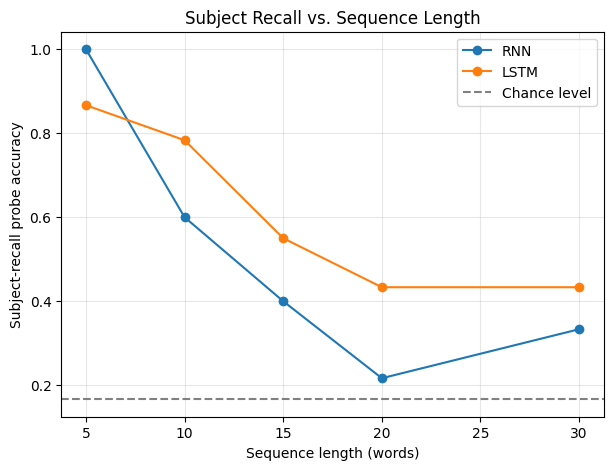

RNN accuracy by length:  {5: 1.0, 10: 0.6, 15: 0.4, 20: 0.22, 30: 0.33}
LSTM accuracy by length: {5: 0.87, 10: 0.78, 15: 0.55, 20: 0.43, 30: 0.43}


In [6]:
if TF_AVAILABLE:
    from sklearn.linear_model import LogisticRegression

    def probe_accuracy(extractor, length):
        Xp, y = probe_data[length]
        hidden = extractor.predict(Xp, verbose=0)
        # Use a fresh, large training set of hidden states at this length to fit the probe
        Xp_train, y_train_probe = make_dataset(300, length, seed=length + 9000)[:2]
        hidden_train = extractor.predict(Xp_train, verbose=0)
        probe = LogisticRegression(max_iter=1000)
        probe.fit(hidden_train, y_train_probe)
        return probe.score(hidden, y)

    rnn_accs = [probe_accuracy(rnn_extractor, l) for l in lengths_to_probe]
    lstm_accs = [probe_accuracy(lstm_extractor, l) for l in lengths_to_probe]

    plt.figure(figsize=(7, 5))
    plt.plot(lengths_to_probe, rnn_accs, marker="o", label="RNN")
    plt.plot(lengths_to_probe, lstm_accs, marker="o", label="LSTM")
    plt.axhline(1 / N_SUBJECTS, color="gray", linestyle="--", label="Chance level")
    plt.xlabel("Sequence length (words)")
    plt.ylabel("Subject-recall probe accuracy")
    plt.title("Subject Recall vs. Sequence Length")
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    print("RNN accuracy by length: ", dict(zip(lengths_to_probe, [round(a, 2) for a in rnn_accs])))
    print("LSTM accuracy by length:", dict(zip(lengths_to_probe, [round(a, 2) for a in lstm_accs])))


**Questions to consider:**
- At what length does the RNN's subject-recall accuracy begin to drop noticeably?
- At what length does the LSTM's accuracy drop?
- What is the approximate accuracy of each model on 30-word sentences?

## Part 3 — Reflection

Write a 200-300 word reflection addressing both of these questions:

1. Both models degrade with increasing sequence length. What does this tell you about the fundamental nature of fixed-size hidden states as a memory mechanism? If you had to design a different kind of memory — one that did not degrade this way — what properties would it need?
2. Your MIPDS system will eventually need to process language inputs. Based on what you observed in this exploration, what would concern you about relying on an LSTM as the language encoder for a system that needs to handle paragraph-length descriptions or captions? What would you want to test before trusting such a system in deployment?

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here, addressing both questions._